#  Ghép ảnh toàn cảnh (Panoramic Photos– Image Stitching)

## Pipeline
- Load và tiền xử lý ảnh (chuyển ảnh xám, chuẩn hóa kích thước nếu cần).
- Trích xuất đặc trưng (feature detection và description).
- So khớp đặc trưng giữa các cặp ảnh.
- Ước lượng phép biến đổi hình học (homography) giữa các ảnh.
- Căn chỉnh ảnh và ghép ảnh để tạo panorama.
- Xửlý vùng chồng lấn và biên ảnh (blending) ở mức cơ bản.

## Load và tiền xử lý ảnh

### Import

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import requests

image_folder = "images"

if not os.path.exists(image_folder):
    os.makedirs(image_folder)
    print(f"Created folder: {image_folder}")

### Load ảnh

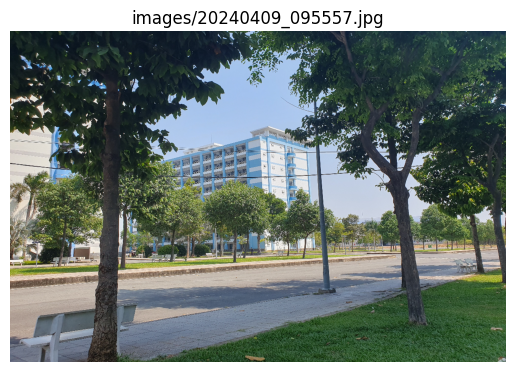

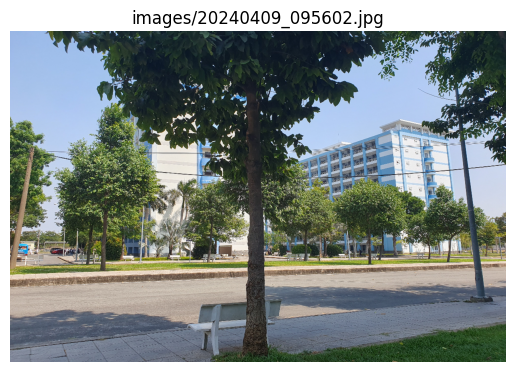

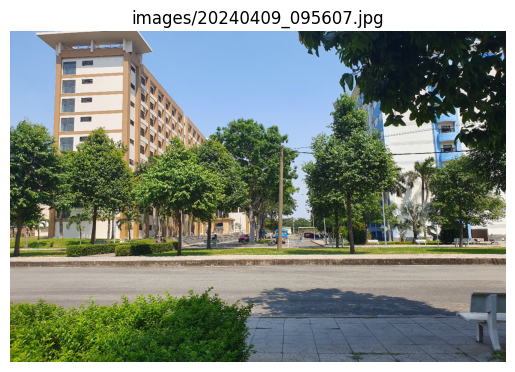

In [65]:
image_paths = [
    "images/20240409_095557.jpg",
    "images/20240409_095602.jpg",
    "images/20240409_095607.jpg",
    #"images/20240409_095613.jpg"
]

images = []
grays = []

for path in image_paths:
    img = cv2.imread(path)
    img = cv2.resize(img, (1200, 800))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure()
    plt.imshow(img)
    plt.title(path)
    plt.axis("off")

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    images.append(img)
    grays.append(gray)

## FEATURE EXTRACTION

In [41]:
def extract_features(gray, method):
    if method == "SIFT":
        detector = cv2.SIFT_create(nfeatures=2000)
    elif method == "BRISK":
        detector = cv2.BRISK_create()

    kp, des = detector.detectAndCompute(gray, None)
    return kp, des

## FEATURE MATCHING

In [61]:
def match_features(des1, des2, method):

    if method in ["BRISK"]:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    else:
        bf = cv2.BFMatcher(cv2.NORM_L2)

    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return good

## TÍNH HOMOGRAPHY

In [16]:
def compute_homography(kp1, kp2, matches):

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

    H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    return H

## WARP + STITCH

In [35]:
def warp_and_stitch(img1, img2, H):

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    result = cv2.warpPerspective(img1, H, (w1 + w2, max(h1, h2)))

    result[0:h2, 0:w2] = img2

    return result

## BLENDING (cơ bản)

In [28]:
def simple_blending(result, img2):

    h2, w2 = img2.shape[:2]

    mask = (result[0:h2, 0:w2] == 0)
    result[0:h2, 0:w2][mask] = img2[mask]

    return result

## Ghép Ảnh

In [32]:
def panorama(images, method):

    pano = images[0]

    for i in range(1, len(images)):

        gray1 = cv2.cvtColor(pano, cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY)

        # 1. Feature
        kp1, des1 = extract_features(gray1, method)
        kp2, des2 = extract_features(gray2, method)

        # 2. Matching
        matches = match_features(des1, des2, method)

        if len(matches) < 5:
            print("Not enough matches")
            continue

        # 3. Homography
        H = compute_homography(kp1, kp2, matches)

        # 4. Warp + Stitch
        pano = warp_and_stitch(pano, images[i], H)

        # 5. Blending
        pano = simple_blending(pano, images[i])

    return pano

## Chạy 2 Phương Pháp

In [66]:
pano_sift = panorama(images, "SIFT")
pano_brisk  = panorama(images, "BRISK")

## Hiển Thị

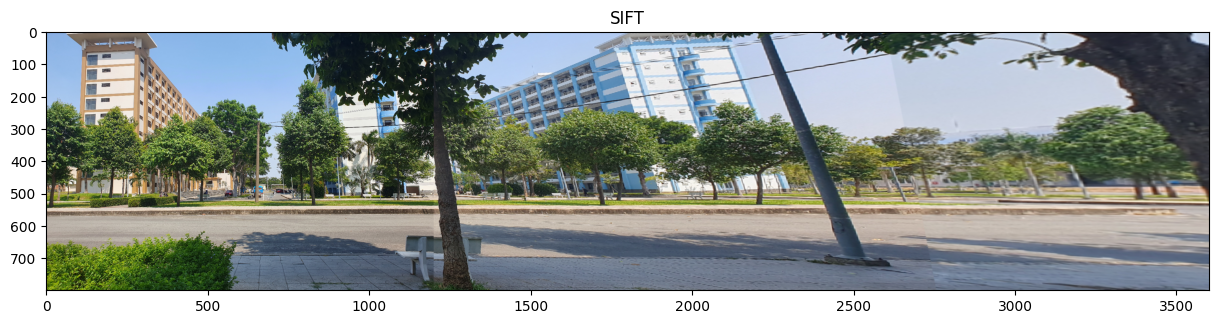

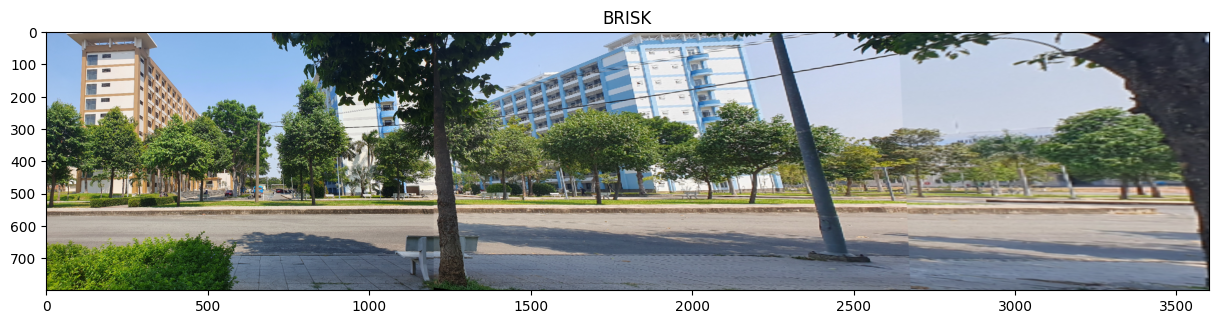

In [67]:
plt.figure(figsize=(15,5))
plt.imshow(pano_sift)
plt.title("SIFT")
plt.show()

plt.figure(figsize=(15,5))
plt.imshow(pano_brisk)
plt.title("BRISK")
plt.show()